# Check CUDA and PyTorch Installation

## Check for NVIDIA drivers

If this shows an error, NVIDA drivers must be installed

In [1]:
!nvidia-smi

Fri Jan  2 16:44:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.44.01              Driver Version: 591.44         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...    On  |   00000000:01:00.0 Off |                  N/A |
| N/A   49C    P3             13W /   30W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!nvcc --version

/bin/bash: line 1: nvcc: command not found


## Update PyTorch

### Clean up install

In [ ]:
%pip uninstall -y torch torchvision torchaudio
%pip install --upgrade pip

### CPU Option

In [ ]:
# CUDA for CPU only
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

### Legacy PyTorch

In [ ]:
# CUDA 12.1 build (works on most modern NVIDIA drivers)
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

### Laest version of NVIDIA enabled pyTorch

In [ ]:
# Newest version
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu130

## Check installation

### Check for pyTorch

In [3]:
!python -c "import torch; print(torch.__version__)"

2.9.1+cu130


### Check for CUDA

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import subprocess
import csv
from datetime import datetime
import matplotlib.pyplot as plt
from collections import deque

In [3]:
print("Torch CUDA version:", torch.version.cuda)
print("Is CUDA available:", torch.cuda.is_available())

Torch CUDA version: 13.0
Is CUDA available: True


### Torch test

In [6]:
print("=" * 50)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA device count:", torch.cuda.device_count())
    print("Current device:", torch.cuda.current_device())
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Running on CPU")

print("=" * 50)

# Simple neural network
class SmallNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

model = SmallNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Dummy data
batch_size = 512
x = torch.randn(batch_size, 1024, device=device)
y = torch.randint(0, 10, (batch_size,), device=device)

# Warm-up
for _ in range(5):
    optimizer.zero_grad()
    loss = criterion(model(x), y)
    loss.backward()
    optimizer.step()

# Timed run
start = time.time()
for _ in range(1000):
    optimizer.zero_grad()
    loss = criterion(model(x), y)
    loss.backward()
    optimizer.step()
end = time.time()

print(f"Final loss: {loss.item():.4f}")
print(f"Time for 1000 iterations: {end - start:.3f} seconds")
print("Model device:", next(model.parameters()).device)
print("Tensor device:", x.device)


PyTorch version: 2.9.1+cu130
CUDA available: True
CUDA device count: 1
Current device: 0
GPU name: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Final loss: 0.0000
Time for 1000 iterations: 7.456 seconds
Model device: cuda:0
Tensor device: cuda:0


### Torch Stress Test

In [7]:
print("="*30)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("PyTorch compiled CUDA:", torch.version.cuda)
print("="*30)

if not torch.cuda.is_available():
    raise SystemExit("No GPU detected. Exiting stress test.")

device = torch.device("cuda")
print("Device name:", torch.cuda.get_device_name(0))
print("Device count:", torch.cuda.device_count())

# Big neural network to stress GPU
class BigNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4096, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

model = BigNet().to(device)
print("Model moved to:", next(model.parameters()).device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Larger dummy data
batch_size = 1024
x = torch.randn(batch_size, 4096, device=device)
y = torch.randint(0, 10, (batch_size,), device=device)

print("Running stress test...")

start = time.time()
for i in range(200):  # larger loop
    optimizer.zero_grad()
    out = model(x)
    loss = criterion(out, y)
    loss.backward()
    optimizer.step()
    if i % 50 == 0:
        print(f"Iteration {i}, Loss {loss.item():.4f}")

end = time.time()
print(f"Completed 200 iters in {end-start:.2f}s")
print("Final loss:", loss.item())


PyTorch version: 2.9.1+cu130
CUDA available: True
PyTorch compiled CUDA: 13.0
Device name: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Device count: 1
Model moved to: cuda:0
Running stress test...
Iteration 0, Loss 2.3015
Iteration 50, Loss 0.0028
Iteration 100, Loss 0.0001
Iteration 150, Loss 0.0001
Completed 200 iters in 6.23s
Final loss: 9.264276013709605e-05


In [8]:
assert torch.cuda.is_available(), "CUDA GPU not detected."

device = torch.device("cuda")
props = torch.cuda.get_device_properties(0)

VRAM_GB = props.total_memory / (1024 ** 3)
GPU_NAME = props.name

print("=" * 60)
print(f"GPU: {GPU_NAME}")
print(f"VRAM: {VRAM_GB:.2f} GB")
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("=" * 60)

# ----------------------------
# Adaptive sizing
# ----------------------------
HIDDEN = int(8192 if VRAM_GB >= 16 else 4096 if VRAM_GB >= 8 else 2048)
DEPTH = int(16 if VRAM_GB >= 16 else 12 if VRAM_GB >= 8 else 8)
BATCH = int(2048 if VRAM_GB >= 16 else 1024 if VRAM_GB >= 8 else 512)

print(f"Model width: {HIDDEN}")
print(f"Model depth: {DEPTH}")
print(f"Batch size: {BATCH}")

# ----------------------------
# Brutal MLP
# ----------------------------
class TortureNet(nn.Module):
    def __init__(self):
        super().__init__()
        layers = [nn.Linear(HIDDEN, HIDDEN), nn.GELU()]
        for _ in range(DEPTH):
            layers += [nn.Linear(HIDDEN, HIDDEN), nn.GELU()]
        layers.append(nn.Linear(HIDDEN, 1000))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = TortureNet().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# AMP for max throughput
scaler = torch.amp.GradScaler()

# ----------------------------
# Dummy data
# ----------------------------
x = torch.randn(BATCH, HIDDEN, device=device)
y = torch.randint(0, 1000, (BATCH,), device=device)

# ----------------------------
# Logging setup
# ----------------------------
logfile = f"gpu_stress_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
with open(logfile, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "time",
        "iteration",
        "loss",
        "gpu_util_%",
        "mem_used_MB",
        "temp_C",
        "power_W"
    ])

def query_gpu():
    cmd = [
        "nvidia-smi",
        "--query-gpu=utilization.gpu,memory.used,temperature.gpu,power.draw",
        "--format=csv,noheader,nounits"
    ]
    out = subprocess.check_output(cmd).decode().strip()
    util, mem, temp, power = map(float, out.split(", "))
    return util, mem, temp, power

# ----------------------------
# Main torture loop
# ----------------------------
print("\n🔥 Starting GPU TORTURE TEST (Ctrl+C to stop)\n")
start = time.time()
i = 0

try:
    while True:
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        torch.cuda.synchronize()

        util, mem, temp, power = query_gpu()

        with open(logfile, "a", newline="") as f:
            csv.writer(f).writerow([
                datetime.now().isoformat(),
                i,
                loss.item(),
                util,
                mem,
                temp,
                power
            ])

        if i % 10 == 0:
            print(
                f"[{i:05d}] "
                f"Loss {loss.item():.3f} | "
                f"GPU {util:5.1f}% | "
                f"VRAM {mem:6.0f} MB | "
                f"{temp:4.0f}C | "
                f"{power:6.1f} W"
            )

        i += 1

except KeyboardInterrupt:
    print("\n🛑 Stress test stopped by user.")
    print(f"Runtime: {time.time() - start:.1f}s")
    print(f"Log saved to: {logfile}")


GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM: 4.00 GB
PyTorch: 2.9.1+cu130
CUDA: 13.0
Model width: 2048
Model depth: 8
Batch size: 512

🔥 Starting GPU TORTURE TEST (Ctrl+C to stop)

[00000] Loss 6.908 | GPU  89.0% | VRAM    943 MB |   48C |   12.1 W
[00010] Loss 6.847 | GPU  42.0% | VRAM    943 MB |   50C |   21.0 W
[00020] Loss 5.891 | GPU  33.0% | VRAM    943 MB |   51C |   21.2 W
[00030] Loss 5.653 | GPU  27.0% | VRAM    943 MB |   52C |   21.2 W
[00040] Loss 5.357 | GPU  41.0% | VRAM    943 MB |   52C |   21.9 W
[00050] Loss 5.254 | GPU  33.0% | VRAM    943 MB |   52C |   21.0 W
[00060] Loss 5.048 | GPU  41.0% | VRAM    943 MB |   53C |   21.9 W
[00070] Loss 4.858 | GPU  41.0% | VRAM    943 MB |   52C |   21.7 W
[00080] Loss 4.927 | GPU  29.0% | VRAM    943 MB |   53C |   21.1 W
[00090] Loss 4.643 | GPU  41.0% | VRAM    943 MB |   54C |   21.8 W
[00100] Loss 4.363 | GPU  36.0% | VRAM    943 MB |   54C |   21.1 W
[00110] Loss 4.120 | GPU  41.0% | VRAM    943 MB |   53C |   21.5 W

GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM: 4.29 GB
PyTorch: 2.9.1+cu130
CUDA (torch): 13.0

🔥 FACTORY VALIDATION RUNNING (Ctrl+C to abort)



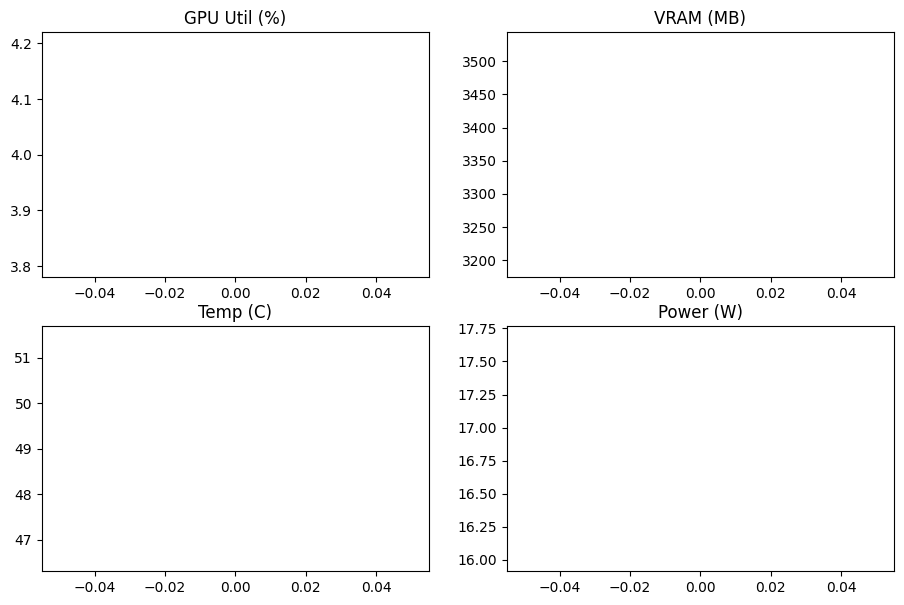

[00000] Batch  1024 |   4.0% |   3359MB |  49C |   16.8W
[00010] Batch  4096 |  21.0% |   3659MB |  51C |   22.9W
[00020] Batch  4096 |  14.0% |   3659MB |  51C |   17.6W
[00030] Batch  4096 |  12.0% |   3659MB |  52C |   18.2W
[00040] Batch  4096 |  12.0% |   3723MB |  52C |   18.4W
[00050] Batch  4096 |  30.0% |   3723MB |  52C |   18.7W
[00060] Batch  4096 |  25.0% |   3755MB |  52C |   18.0W
[00070] Batch  4096 |  30.0% |   3755MB |  52C |   17.4W
[00080] Batch  4096 |  32.0% |   3755MB |  52C |   15.5W
[00090] Batch  4096 |  44.0% |   3755MB |  53C |   15.2W
[00100] Batch  4096 |  26.0% |   3755MB |  52C |   14.7W
[00110] Batch  4096 |  14.0% |   3755MB |  52C |   17.2W
[00120] Batch  4096 |  21.0% |   3755MB |  52C |   15.9W
[00130] Batch  4096 |  36.0% |   3755MB |  53C |   16.5W
[00140] Batch  4096 |  22.0% |   3755MB |  53C |   16.1W
[00150] Batch  4096 |  15.0% |   3755MB |  52C |   15.6W
[00160] Batch  4096 |  12.0% |   3755MB |  54C |   18.1W
[00170] Batch  4096 |  29.0% | 

In [4]:
assert torch.cuda.is_available(), "CUDA GPU not detected"

device = "cuda"
props = torch.cuda.get_device_properties(0)

GPU_NAME = props.name
VRAM_GB = props.total_memory / 1e9

print("=" * 80)
print(f"GPU: {GPU_NAME}")
print(f"VRAM: {VRAM_GB:.2f} GB")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA (torch): {torch.version.cuda}")
print("=" * 80)

# -----------------------------
# Factory-grade parameters
# -----------------------------
DURATION_SEC = 600          # 10 minutes
TARGET_UTIL = 92
STREAMS = 4                # concurrent kernels
BASE_DIM = 4096 if VRAM_GB >= 6 else 2048
MAX_BATCH = 8192 if VRAM_GB >= 6 else 4096
FP32_RATIO = 0.25           # mixed FP16/FP32 stress
VRAM_PRESSURE_GB = 0.7 * VRAM_GB

# -----------------------------
# GPU telemetry
# -----------------------------
def gpu_stats():
    out = subprocess.check_output([
        "nvidia-smi",
        "--query-gpu=utilization.gpu,memory.used,temperature.gpu,power.draw",
        "--format=csv,noheader,nounits"
    ]).decode().strip()
    return list(map(float, out.split(", ")))

# -----------------------------
# Logging
# -----------------------------
logfile = f"gpu_factory_validation_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
with open(logfile, "w", newline="") as f:
    csv.writer(f).writerow([
        "time","iter","batch","util","mem_MB","temp_C","power_W","status"
    ])

# -----------------------------
# Live plotting
# -----------------------------
plt.ion()
fig, axs = plt.subplots(2, 2, figsize=(11, 7))
metrics = {k: deque(maxlen=300) for k in ["util","mem","temp","power"]}

def update_plots():
    titles = [("util","GPU Util (%)"),("mem","VRAM (MB)"),
              ("temp","Temp (C)"),("power","Power (W)")]
    for ax,(k,title) in zip(axs.flat,titles):
        ax.cla()
        ax.plot(metrics[k])
        ax.set_title(title)
    plt.pause(0.001)

# -----------------------------
# CUDA streams
# -----------------------------
streams = [torch.cuda.Stream() for _ in range(STREAMS)]

# -----------------------------
# Workload buffers
# -----------------------------
batch = 512
A_fp16 = torch.randn(batch, BASE_DIM, device=device, dtype=torch.float16)
B_fp16 = torch.randn(BASE_DIM, BASE_DIM, device=device, dtype=torch.float16)

A_fp32 = torch.randn(batch, BASE_DIM, device=device, dtype=torch.float32)
B_fp32 = torch.randn(BASE_DIM, BASE_DIM, device=device, dtype=torch.float32)

# VRAM pressure buffer (fragmentation stress)
vram_buffers = []
alloc_target = int(VRAM_PRESSURE_GB * 1024**3)

def apply_vram_pressure():
    allocated = 0
    vram_buffers.clear()
    while allocated < alloc_target:
        t = torch.empty((1024,1024), device=device, dtype=torch.float32)
        vram_buffers.append(t)
        allocated += t.element_size() * t.nelement()

apply_vram_pressure()

print("\n🔥 FACTORY VALIDATION RUNNING (Ctrl+C to abort)\n")

start = time.time()
i = 0
status = "OK"

try:
    while time.time() - start < DURATION_SEC:
        util, mem, temp, power = gpu_stats()

        # Adaptive ramp
        if util < TARGET_UTIL and batch < MAX_BATCH:
            batch *= 2
            A_fp16 = torch.randn(batch, BASE_DIM, device=device, dtype=torch.float16)
            A_fp32 = torch.randn(batch, BASE_DIM, device=device, dtype=torch.float32)

        # Multi-stream concurrent GEMMs
        for s in streams:
            with torch.cuda.stream(s):
                with torch.amp.autocast("cuda"):
                    C1 = A_fp16 @ B_fp16
                if torch.rand(1).item() < FP32_RATIO:
                    C2 = A_fp32 @ B_fp32

        torch.cuda.synchronize()

        # Numerical sanity
        if torch.isnan(C1).any() or torch.isinf(C1).any():
            status = "NUMERICAL_ERROR"
            raise RuntimeError("NaN/Inf detected")

        util, mem, temp, power = gpu_stats()

        metrics["util"].append(util)
        metrics["mem"].append(mem)
        metrics["temp"].append(temp)
        metrics["power"].append(power)
        update_plots()

        with open(logfile, "a", newline="") as f:
            csv.writer(f).writerow([
                datetime.now().isoformat(),
                i,
                batch,
                util,
                mem,
                temp,
                power,
                status
            ])

        if i % 10 == 0:
            print(
                f"[{i:05d}] "
                f"Batch {batch:5d} | "
                f"{util:5.1f}% | "
                f"{mem:6.0f}MB | "
                f"{temp:3.0f}C | "
                f"{power:6.1f}W"
            )

        i += 1

except KeyboardInterrupt:
    status = "ABORTED"

except Exception as e:
    status = f"FAIL: {e}"
    print("\n❌ VALIDATION FAILURE:", e)

finally:
    print("\n================ VALIDATION COMPLETE ================")
    print("Status:", status)
    print("Runtime:", f"{time.time() - start:.1f}s")
    print("Log:", logfile)
    plt.ioff()
    plt.show()
